# Étape 3 : Analyse structurelle du graphe CV–Job

Ce notebook étudie uniquement la structure du graphe biparti initial. Il ne détecte pas de
communautés et ne réalise ni prédiction, ni apprentissage.

## 1. Chargement et vérification

Le graphe est rechargé depuis le pickle produit à l'étape précédente. Ces assertions vérifient
simplement que nous analysons le bon objet : un graphe simple, non orienté et biparti.

In [1]:
from pathlib import Path
import json
import pickle
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
FIGURES_DIR = ROOT / "figures" / "step3"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with (ROOT / "data" / "processed" / "cv_job_graph.pkl").open("rb") as file:
    G = pickle.load(file)

cv_nodes = [node for node, data in G.nodes(data=True) if data["node_type"] == "CV"]
job_nodes = [node for node, data in G.nodes(data=True) if data["node_type"] == "Job"]

assert G.number_of_nodes() == 12_500
assert G.number_of_edges() == 75_000
assert len(cv_nodes) == 10_000
assert len(job_nodes) == 2_500
assert nx.is_bipartite(G)
print("Graphe correctement chargé et validé.")

Graphe correctement chargé et validé.


## 2. Nombre de nœuds et d'arêtes

Un graphe s'écrit $G=(V,E)$. Le nombre de nœuds est $n=|V|$ et le nombre d'arêtes est
$m=|E|$. Ici, les nœuds sont les CV et les Jobs ; les arêtes sont les correspondances observées.

In [2]:
n = G.number_of_nodes()
m = G.number_of_edges()
display(pd.Series({"n_nodes": n, "n_edges": m, "n_cv": len(cv_nodes), "n_jobs": len(job_nodes)}, name="valeur").to_frame())

,valeur
n_nodes,12500
n_edges,75000
n_cv,10000
n_jobs,2500


## 3. Degrés

Le **degré** $k(v)$ d'un nœud est son nombre de voisins. Pour un CV, il indique le nombre de Jobs
auxquels il correspond ; pour un Job, le nombre de CV pertinents

Nous calculons les degrés par partition, vérifions l'identité $\sum_v k(v)=2m$, puis affichons
les nœuds les plus connectés avec des attributs permettant de les interpréter.

In [3]:
degrees = dict(G.degree())
degree_cv = pd.Series({node: degrees[node] for node in cv_nodes}, name="degree")
degree_job = pd.Series({node: degrees[node] for node in job_nodes}, name="degree")

assert sum(degrees.values()) == 2 * m

degree_summary = {
    "average_degree_global": 2 * m / n,
    "average_degree_cv": float(degree_cv.mean()),
    "average_degree_job": float(degree_job.mean()),
    "min_degree_cv": int(degree_cv.min()),
    "median_degree_cv": float(degree_cv.median()),
    "max_degree_cv": int(degree_cv.max()),
    "min_degree_job": int(degree_job.min()),
    "median_degree_job": float(degree_job.median()),
    "max_degree_job": int(degree_job.max()),
}
display(pd.Series(degree_summary, name="valeur").to_frame())

def ranking_table(scores, nodes, columns, top_n=10):
    selected = sorted(nodes, key=lambda node: scores[node], reverse=True)[:top_n]
    rows = []
    for node in selected:
        row = {"node_id": node, "score": scores[node]}
        row.update({column: G.nodes[node].get(column) for column in columns})
        rows.append(row)
    return pd.DataFrame(rows)

print("10 CV de plus haut degré")
display(ranking_table(degrees, cv_nodes, ["role", "seniority", "industry"]))
print("10 Jobs de plus haut degré")
display(ranking_table(degrees, job_nodes, ["job_title", "seniority", "industry"]))

,valeur
average_degree_global,12.0
average_degree_cv,7.5
average_degree_job,30.0
min_degree_cv,0.0
median_degree_cv,7.0
max_degree_cv,27.0
min_degree_job,30.0
median_degree_job,30.0
max_degree_job,30.0


10 CV de plus haut degré


,node_id,score,role,seniority,industry
0,R_006412,27,Operations Manager,Mid,Travel
1,R_008878,23,Business Development Manager,Junior,FinTech
2,R_004339,22,Business Development Manager,Mid,Cybersecurity
3,R_007153,22,Technical Product Manager,Junior,Retail
4,R_008358,22,Customer Success Associate,Senior,EdTech
5,R_008703,22,Business Development Manager,Mid,Gaming
6,R_001326,21,Data Analyst,Mid,Travel
7,R_003058,21,Operations Manager,Senior,Retail
8,R_007661,21,Project Manager,Junior,FinTech
9,R_000207,20,Financial Analyst,Junior,E-commerce


10 Jobs de plus haut degré


,node_id,score,job_title,seniority,industry
0,J_000000,30,Project Manager,Senior,Retail
1,J_000001,30,Customer Success Associate,Senior,EdTech
2,J_000002,30,FP&A Analyst,Junior,Travel
3,J_000003,30,Full Stack Engineer,Junior,Cybersecurity
4,J_000004,30,Associate Product Manager,Senior,SaaS
5,J_000005,30,Sales Representative,Senior,Healthcare
6,J_000006,30,Customer Success Associate,Mid,E-commerce
7,J_000007,30,BI Analyst,Senior,FinTech
8,J_000008,30,Content Marketer,Senior,Logistics
9,J_000009,30,Project Manager,Mid,Cybersecurity


## 4. Distribution des degrés

Une moyenne résume la tendance centrale mais cache la dispersion : deux graphes peuvent avoir le
même degré moyen avec des répartitions très différentes. Les distributions montrent combien de
nœuds ont chaque degré, sans afficher individuellement les 12 500 nœuds. Les deux partitions sont
séparées car un degré de CV et un degré de Job n'ont pas la même échelle ni la même interprétation.

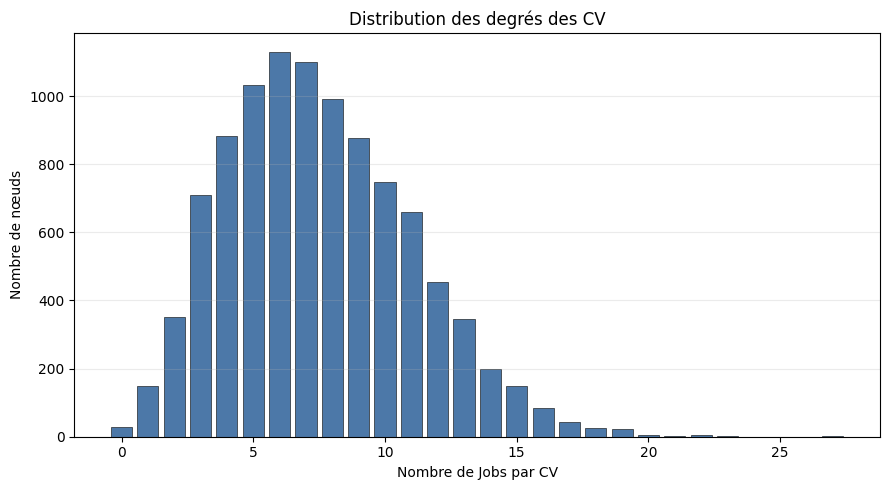

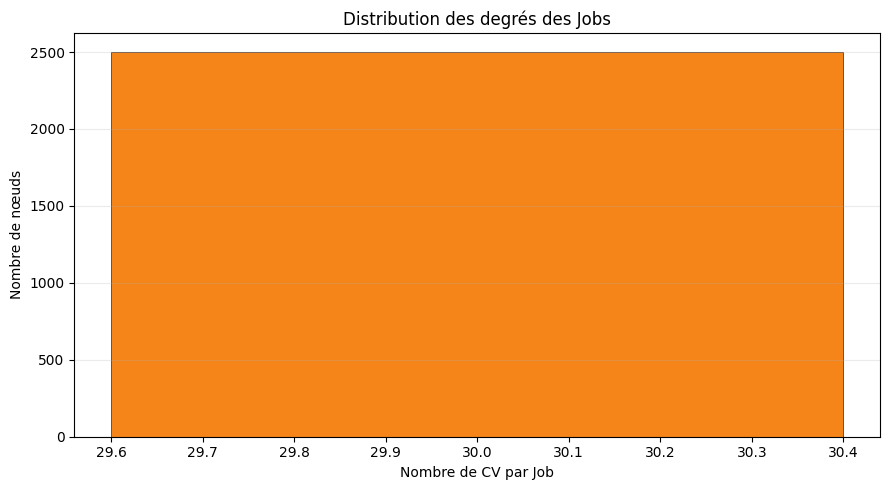

,nombre_jobs
degree,
30,2500


Tous les Jobs ont le même degré : propriété régulière du dataset synthétique, pas constat naturel sur le marché réel.


In [4]:
def save_degree_distribution(values, title, xlabel, path, color):
    counts = values.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(counts.index, counts.values, color=color, edgecolor="black", linewidth=0.4)
    ax.set(title=title, xlabel=xlabel, ylabel="Nombre de nœuds")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

save_degree_distribution(degree_cv, "Distribution des degrés des CV", "Nombre de Jobs par CV", FIGURES_DIR / "cv_degree_distribution.png", "#4C78A8")
save_degree_distribution(degree_job, "Distribution des degrés des Jobs", "Nombre de CV par Job", FIGURES_DIR / "job_degree_distribution.png", "#F58518")

job_degree_counts = degree_job.value_counts().sort_index()
display(job_degree_counts.rename("nombre_jobs").to_frame())
if len(job_degree_counts) == 1:
    print("Tous les Jobs ont le même degré : propriété régulière du dataset synthétique, pas constat naturel sur le marché réel.")

## 5. Densité bipartite

La densité mesure la proportion d'arêtes observées parmi les arêtes possibles. Dans un graphe
biparti, seules les paires CV–Job sont possibles, donc la mesure adaptée est

$$D_{bipartite}=\frac{m}{n_{CV}n_{Job}}.$$

La densité classique de NetworkX divise par toutes les paires de nœuds, y compris CV–CV et
Job–Job, interdites dans notre modèle. Nous l'affichons seulement pour comparaison.

In [5]:
bipartite_density = m / (len(cv_nodes) * len(job_nodes))
classic_density = nx.density(G)
display(pd.Series({"bipartite_density": bipartite_density, "classic_density_for_comparison": classic_density}, name="valeur").to_frame())

,valeur
bipartite_density,0.00300
classic_density_for_comparison,0.00096


## 6. Composantes connexes et isolés

Une **composante connexe** est un groupe de nœuds reliés entre eux par des chemins. Un **isolé**
est un nœud de degré nul. Une grande composante dominante indique qu'une large part des CV et Jobs
appartient au même système de correspondances ; les isolés signaleraient des profils ou offres sans
aucun lien. `G_lcc` est une copie du sous-graphe de la plus grande composante ; `G` reste inchangé.

In [6]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
component_sizes = [len(component) for component in components]
largest_component = components[0]
G_lcc = G.subgraph(largest_component).copy()
isolates = list(nx.isolates(G))
n_isolated_cv = sum(G.nodes[node]["node_type"] == "CV" for node in isolates)
n_isolated_jobs = sum(G.nodes[node]["node_type"] == "Job" for node in isolates)

component_summary = {
    "n_connected_components": len(components),
    "largest_component_size": len(largest_component),
    "largest_component_fraction": len(largest_component) / n,
    "n_isolates": len(isolates),
    "n_isolated_cv": n_isolated_cv,
    "n_isolated_jobs": n_isolated_jobs,
}
display(pd.Series(component_summary, name="valeur").to_frame())
display(pd.Series(component_sizes[:10], index=range(1, min(10, len(component_sizes)) + 1), name="taille").rename_axis("rang_composante").to_frame())

,valeur
n_connected_components,36.00000
largest_component_size,3102.00000
largest_component_fraction,0.24816
n_isolates,29.00000
n_isolated_cv,29.00000
n_isolated_jobs,0.00000


,taille
rang_composante,
1,3102
2,1628
3,1565
4,1562
5,1559
6,1550
7,1505
8,1
9,1


## 7. Approximation de la longueur moyenne des chemins

La longueur d'un **plus court chemin** est le nombre minimal d'arêtes pour relier deux nœuds. Deux
nœuds de composantes différentes n'ont pas de chemin, d'où le calcul dans `G_lcc`. Calculer toutes
les paires serait inutilement coûteux ici. nous tirons des paires
aléatoires, mais nous en utilisons 100 pour une estimation plus stable. La seed rend le résultat
reproductible. Les paires sont distinctes et chaque paire contient deux nœuds différents.

In [7]:
def approx_average_shortest_path_length(G_component, n_pairs=100, seed=42):
    rng = random.Random(seed)
    nodes = list(G_component.nodes())
    pairs = set()
    while len(pairs) < n_pairs:
        u, v = rng.sample(nodes, 2)
        pairs.add(tuple(sorted((u, v))))
    distances = [nx.shortest_path_length(G_component, u, v) for u, v in pairs]
    return {
        "n_pairs": n_pairs,
        "seed": seed,
        "mean": float(np.mean(distances)),
        "median": float(np.median(distances)),
        "minimum": int(np.min(distances)),
        "maximum": int(np.max(distances)),
    }

path_stats = approx_average_shortest_path_length(G_lcc, n_pairs=100, seed=42)
display(pd.Series(path_stats, name="valeur").to_frame())

,valeur
n_pairs,100.00
seed,42.00
mean,4.38
median,4.00
minimum,2.00
maximum,6.00


## 8. Centralité de degré adaptée au biparti

La centralité classique $k(v)/(n-1)$ suppose que tout nœud peut être relié à tous les autres.
Ici, un CV ne peut être relié qu'aux Jobs et inversement. La normalisation naturelle est donc
$k(CV)/n_{Jobs}$ pour un CV et $k(Job)/n_{CV}$ pour un Job. Nous conservons le degré brut et cette
version comparable à l'intérieur de chaque partition.

In [8]:
bipartite_degree_centrality = {
    node: degrees[node] / (len(job_nodes) if G.nodes[node]["node_type"] == "CV" else len(cv_nodes))
    for node in G.nodes()
}
print("Centralité bipartite calculée pour", len(bipartite_degree_centrality), "nœuds.")

Centralité bipartite calculée pour 12500 nœuds.


## 9. PageRank

PageRank attribue plus d'importance à un nœud lorsqu'il est relié à des nœuds eux-mêmes importants.
À chaque itération, une fraction $\alpha$ du score suit les arêtes et une fraction $1-\alpha$
représente la **téléportation**, qui stabilise le calcul. Le TP illustrait ce principe par puissance
itérée ; sur ce grand graphe nous utilisons `nx.pagerank`, fiable et efficace, avec $\alpha=0{,}85$.
Dans un graphe biparti non orienté, le score reste structurel : il ne prouve pas une qualité métier.

In [9]:
pagerank = nx.pagerank(G, alpha=0.85, max_iter=1000, tol=1e-10)
pagerank_sum = sum(pagerank.values())
assert np.isclose(pagerank_sum, 1.0)
print("Somme des scores PageRank :", pagerank_sum)
print("Top 10 CV par PageRank")
display(ranking_table(pagerank, cv_nodes, ["role", "seniority", "industry"]))
print("Top 10 Jobs par PageRank")
display(ranking_table(pagerank, job_nodes, ["job_title", "seniority", "industry"]))

Somme des scores PageRank : 0.9999999999999999
Top 10 CV par PageRank


,node_id,score,role,seniority,industry
0,R_006412,0.000151,Operations Manager,Mid,Travel
1,R_007153,0.000141,Technical Product Manager,Junior,Retail
2,R_008878,0.000135,Business Development Manager,Junior,FinTech
3,R_008703,0.000131,Business Development Manager,Mid,Gaming
4,R_004339,0.000130,Business Development Manager,Mid,Cybersecurity
5,R_001326,0.000125,Data Analyst,Mid,Travel
6,R_008358,0.000123,Customer Success Associate,Senior,EdTech
7,R_007836,0.000123,Associate Product Manager,Senior,E-commerce
8,R_003058,0.000122,Operations Manager,Senior,Retail
9,R_007661,0.000121,Project Manager,Junior,FinTech


Top 10 Jobs par PageRank


,node_id,score,job_title,seniority,industry
0,J_001810,0.000226,Account Executive,Junior,Travel
1,J_002258,0.000225,Technical Product Manager,Junior,FinTech
2,J_001662,0.000224,Associate Product Manager,Mid,FinTech
3,J_000314,0.000223,Product Manager,Senior,Gaming
4,J_000127,0.000222,Product Manager,Junior,Logistics
5,J_000853,0.000221,Product Manager,Junior,Travel
6,J_002429,0.000220,Technical Product Manager,Mid,FinTech
7,J_002106,0.000219,Associate Product Manager,Junior,Healthcare
8,J_000620,0.000219,Technical Product Manager,Mid,SaaS
9,J_002362,0.000219,Technical Product Manager,Junior,EdTech


## 10. Betweenness centrality approximée

La betweenness d'un nœud mesure la part des plus courts chemins qui le traversent : un score élevé
peut signaler un **pont** entre différentes zones du graphe.Le calcul exact sur 12 500 nœuds serait
coûteux. NetworkX l'approxime ici à partir de `k=100` sources tirées avec `seed=42`, compromis entre
temps de calcul et stabilité. Les scores restent des estimations.

In [10]:
BETWEENNESS_K = 100
BETWEENNESS_SEED = 42
betweenness_approx = nx.betweenness_centrality(
    G, k=BETWEENNESS_K, normalized=True, seed=BETWEENNESS_SEED
)
print("Top 10 CV par betweenness approximée")
display(ranking_table(betweenness_approx, cv_nodes, ["role", "seniority", "industry"]))
print("Top 10 Jobs par betweenness approximée")
display(ranking_table(betweenness_approx, job_nodes, ["job_title", "seniority", "industry"]))

Top 10 CV par betweenness approximée


,node_id,score,role,seniority,industry
0,R_009443,0.000768,Financial Analyst,Junior,Cybersecurity
1,R_003149,0.000675,Financial Analyst,Junior,Healthcare
2,R_003055,0.000670,Operations Manager,Junior,EdTech
3,R_009300,0.000583,Junior Accountant,Junior,FinTech
4,R_004867,0.000550,Operations Manager,Junior,E-commerce
5,R_003212,0.000547,Financial Analyst,Mid,SaaS
6,R_004426,0.000460,Financial Analyst,Senior,Retail
7,R_007520,0.000454,Junior Accountant,Mid,Retail
8,R_007986,0.000442,Financial Analyst,Junior,SaaS
9,R_009226,0.000436,Project Manager,Senior,Logistics


Top 10 Jobs par betweenness approximée


,node_id,score,job_title,seniority,industry
0,J_001761,0.003275,Project Manager,Junior,Travel
1,J_001051,0.003065,Project Manager,Junior,EdTech
2,J_000889,0.002908,Program Coordinator,Mid,Cybersecurity
3,J_001367,0.002554,Financial Analyst,Junior,Retail
4,J_000352,0.002545,Operations Manager,Senior,Cybersecurity
5,J_001821,0.001606,Project Manager,Mid,Healthcare
6,J_001105,0.001504,Operations Manager,Mid,E-commerce
7,J_000875,0.001406,Project Manager,Junior,Cybersecurity
8,J_001962,0.001397,Project Manager,Senior,Healthcare
9,J_000469,0.001349,FP&A Analyst,Junior,Cybersecurity


## 11. Pourquoi ne pas calculer le clustering classique ?

 le clustering classique à partir des triangles autour d'un nœud. Or un graphe
biparti pur ne peut contenir aucun triangle : une fermeture en trois arêtes exigerait une arête
CV–CV ou Job–Job, toutes deux interdites. Le coefficient classique serait donc nul par construction
et ne serait pas informatif. Il existe des variantes bipartites, mais elles ne sont pas demandées
ici ; nous évitons donc un calcul inutile.

## 12. Visualisation d'un petit sous-graphe

Dessiner 12 500 nœuds et 75 000 arêtes produirait une image illisible. Nous choisissons le Job de
plus haut degré et au maximum 20 de ses CV voisins. Une disposition bipartite place les deux types
de nœuds sur deux axes distincts ; les couleurs distinguent CV, Job et liens de matching.

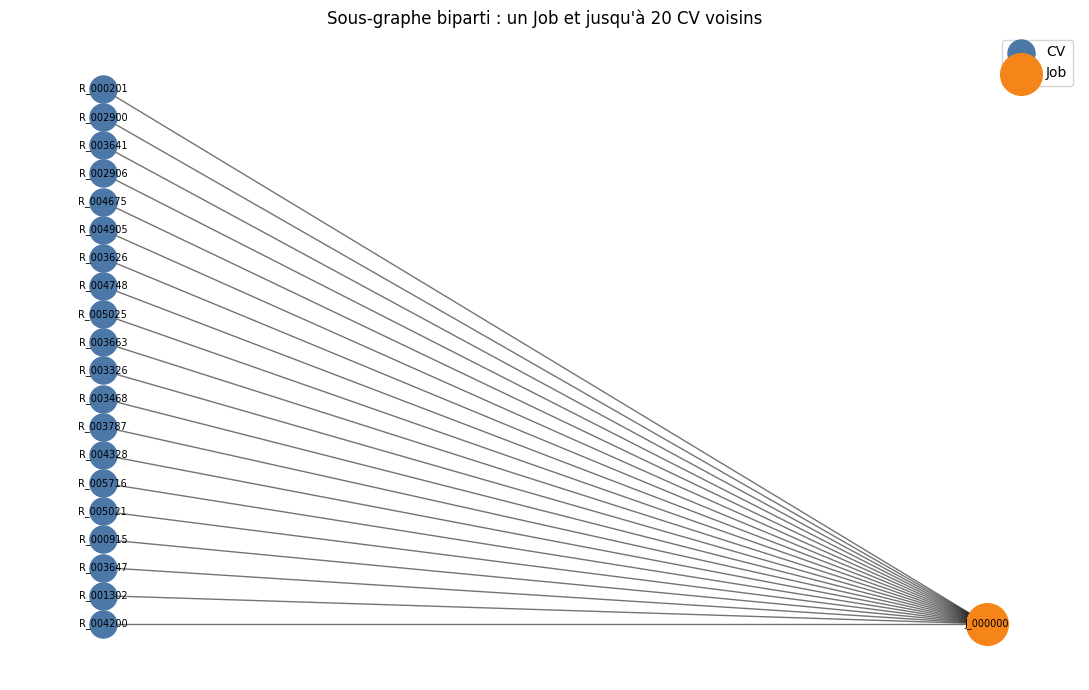

In [11]:
center_job = degree_job.idxmax()
sample_cv_nodes = sorted(G.neighbors(center_job))[:20]
sample_nodes = sample_cv_nodes + [center_job]
sample_graph = G.subgraph(sample_nodes).copy()
positions = nx.bipartite_layout(sample_graph, sample_cv_nodes, align="vertical")

fig, ax = plt.subplots(figsize=(11, 7))
nx.draw_networkx_nodes(sample_graph, positions, nodelist=sample_cv_nodes, node_color="#4C78A8", node_size=380, label="CV", ax=ax)
nx.draw_networkx_nodes(sample_graph, positions, nodelist=[center_job], node_color="#F58518", node_size=900, label="Job", ax=ax)
nx.draw_networkx_edges(sample_graph, positions, width=1, alpha=0.55, ax=ax)
nx.draw_networkx_labels(sample_graph, positions, font_size=7, ax=ax)
ax.set_title("Sous-graphe biparti : un Job et jusqu'à 20 CV voisins")
ax.legend()
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sample_bipartite_subgraph.png", dpi=170, bbox_inches="tight")
plt.show()

## 13. Tableau des métriques par nœud

Une ligne est créée par nœud afin de réutiliser plus tard les mesures structurelles comme features.
Les attributs sémantiques absents d'un type de nœud restent vides ; aucune information n'est inventée.

In [12]:
node_metrics_rows = []
for node, data in G.nodes(data=True):
    node_metrics_rows.append({
        "node_id": node,
        "node_type": data["node_type"],
        "degree": degrees[node],
        "bipartite_degree_centrality": bipartite_degree_centrality[node],
        "pagerank": pagerank[node],
        "betweenness_approx": betweenness_approx[node],
        "role": data.get("role"),
        "job_title": data.get("job_title"),
        "seniority": data.get("seniority"),
        "industry": data.get("industry"),
    })

node_metrics = pd.DataFrame(node_metrics_rows)
node_metrics.to_csv(RESULTS_DIR / "step3_node_metrics.csv", index=False)
display(node_metrics.head())
print("Dimensions :", node_metrics.shape)

,node_id,node_type,degree,bipartite_degree_centrality,pagerank,betweenness_approx,role,job_title,seniority,industry
0,R_000000,CV,6,0.0024,0.000045,2.183560e-06,Software Engineer,None,Senior,EdTech
1,R_000001,CV,9,0.0036,0.000063,6.387242e-06,Marketing Manager,None,Junior,E-commerce
2,R_000002,CV,9,0.0036,0.000061,6.392080e-07,Full Stack Engineer,None,Mid,FinTech
3,R_000003,CV,6,0.0024,0.000044,9.530514e-06,Data Analyst,None,Junior,Healthcare
4,R_000004,CV,5,0.0020,0.000039,4.071342e-06,BI Analyst,None,Junior,Gaming


Dimensions : (12500, 10)


## 14. Résumé structurel

Les résultats principaux et les paramètres des approximations sont enregistrés dans un fichier
JSON reproductible. Les valeurs sont converties en types Python standards pour la sérialisation.

In [13]:
structural_summary = {
    "n_nodes": n,
    "n_edges": m,
    "n_cv": len(cv_nodes),
    "n_jobs": len(job_nodes),
    **degree_summary,
    "bipartite_density": bipartite_density,
    **component_summary,
    "approx_shortest_path": path_stats,
    "pagerank_alpha": 0.85,
    "pagerank_sum": pagerank_sum,
    "betweenness_approximation": {"k": BETWEENNESS_K, "seed": BETWEENNESS_SEED, "normalized": True},
}

(RESULTS_DIR / "step3_structural_summary.json").write_text(
    json.dumps(structural_summary, indent=2, ensure_ascii=False), encoding="utf-8"
)
display(pd.Series(structural_summary, name="valeur").to_frame())

,valeur
n_nodes,12500
n_edges,75000
n_cv,10000
n_jobs,2500
average_degree_global,12.0
average_degree_cv,7.5
average_degree_job,30.0
min_degree_cv,0
median_degree_cv,7.0
max_degree_cv,27


## Interprétation des résultats

- **Graphe sparse :** la densité bipartite vaut `0,003`, soit seulement **0,3 %** des couples
  CV–Job possibles. Le graphe est donc très peu dense, même en utilisant la définition adaptée au
  biparti.
- **Nombre de Jobs par CV :** un CV est relié en moyenne à **7,5 Jobs** (médiane `7`). Les degrés
  vont de `0` à `27` : quelques CV sont nettement plus connectés que la majorité, mais aucun ne se
  rapproche des 2 500 Jobs possibles.
- **Régularité des Jobs :** les 2 500 Jobs ont tous exactement **30 CV pertinents**. Cette absence
  totale de dispersion vient manifestement de la construction du dataset synthétique ; elle ne doit
  pas être présentée comme une propriété naturelle du marché du travail.
- **Composantes :** le graphe contient `36` composantes. La plus grande regroupe `3 102` nœuds,
  soit **24,816 %** du graphe. Il n'existe donc pas une composante unique dominant presque tout le
  réseau. Les distances échantillonnées dans cette composante ont une moyenne de `4,38`, une
  médiane de `4` et vont de `2` à `6` arêtes.
- **Isolés :** `29` CV sont isolés et aucun Job ne l'est. Cela est compatible avec le mécanisme des
  matches : chaque Job reçoit 30 CV, alors que certains CV ne sont sélectionnés par aucun Job.
- **Profils centraux :** le CV de degré maximal est `R_006412` (Operations Manager, Mid, Travel),
  avec `27` liens. Les CV en tête par degré/PageRank incluent notamment des profils Operations,
  Business Development et Product Management. La betweenness approximée fait davantage ressortir
  des Financial Analysts, Junior Accountants et Operations Managers ; elle mesure un rôle de pont,
  pas seulement le nombre de liens.
- **Degré et PageRank :** les classements ne sont pas exactement identiques, car PageRank tient
  compte de l'importance des voisins. Cette différence est particulièrement visible chez les Jobs :
  ils ont tous le même degré (`30`), mais des PageRank différents selon les CV auxquels ils sont
  reliés. Ces écarts restent des observations structurelles et ne démontrent aucune supériorité
  professionnelle ou causalité métier.
